<a id=0></a>
# 4.Categorical Plot

---
### [1.SearbornのデータセットからDataFrameを作成 ](#1)
### [2.欠損値の処理 ](#2)
### [3.欠損した年齢を考えてみる（プロットの例を示す）](#3)
### [4.カテゴリカルプロット](#4)
---

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
<a id=1></a>
[Topへ](#0)

---
## 1. SearbornのデータセットからDataFrameを作成

* データセット(Titanic)を読み込む
* データセットの理解と整理、Kaggleの紹介
* 重複カラムの処理
---

データセット(Titanic)を読み込む

In [9]:
# sns.get_dataset_names()に対して
# このような関数はないというエラー、もしくは空のリストがリターンされるかもしれません
# その場合は続くセルのload_datasetもエラーになると思われます
# ダウンロードいただいている"sns_datasets"内のcsvファイルを読み込んで学習を先へお進めください
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

データセットの理解と整理、Kaggleの紹介

<p>
    <a href="https://www.kaggle.com/competitions/titanic/data" target="_blank" rel="noreferrer noopener">
        Kaggle Dataset Titanic のページへ
    </a>
</p>

    survival : Survival	0 = No, 1 = Yes  
    pclass   : Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd  
    sex	  : Sex	  
    age      : Age in years  	
    sibsp    : # of siblings / spouses aboard the Titanic  (兄弟姉妹 / 配偶者)  
    parch    : # of parents / children aboard the Titanic	(親 / 子)  
    fare     : Passenger fare	
    embarked : Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton  
    who      : man or female or child
    class, who, adult_male, deck, embark_town, alive, alone
    ※ 一部変更しています

In [48]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


重複カラムの処理（'alive', 'class', 'adult_male', 'embark_town', 'alone'）

<p style="background-color:#ffd">
    'alive', 'class', 'adult_male', 'embark_town', 'alone' のカラムを削除 
    </p>

In [17]:
df['survived'].unique()
df['alive'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
# これいいな、重複を見つけたい時に使えそう、0はnoだし、1はYesで対応してる
df[['survived', 'alive']].value_counts()

survived  alive
0         no       549
1         yes      342
Name: count, dtype: int64

In [21]:
df[['class', 'pclass']].value_counts()

class   pclass
Third   3         491
First   1         216
Second  2         184
Name: count, dtype: int64

In [25]:
df[['embarked', 'embark_town']].value_counts()

embarked  embark_town
S         Southampton    644
C         Cherbourg      168
Q         Queenstown      77
Name: count, dtype: int64

In [27]:
df[['adult_male', 'who']].value_counts()
# これもTrueはManだけだし、adult_maleを消しても何ら問題ない

adult_male  who  
True        man      537
False       woman    271
            child     83
Name: count, dtype: int64

In [35]:
df[(df['sibsp'] == 0) & (df['parch'] == 0)]['alone'].unique()
# 連れ0家族0なら、aloneはTrueなんでは？そうなら、別にalone要らないんでは？

array([ True])

In [40]:
df[(df['sibsp'] != 0) | (df['parch'] != 0)]['alone'].unique()
# 連れ0か家族0なら、aloneはFalseなんでは？　｜はorの意味（初知り）

array([False])

In [50]:
df.drop(['alive', 'class', 'adult_male', 'embark_town', 'alone'], axis=1, inplace=True)
df.head()

KeyError: "['alive', 'class', 'adult_male', 'embark_town', 'alone'] not found in axis"

In [52]:
df.shape

(891, 10)

---
<a id=2></a>
[Topへ](#0)

---
## 2. 欠損値の処理

* 欠損値の確認
* 欠損値の処理('deck')
* 欠損値の処理('embarked')：予測を試みる
---

欠損値の確認

In [54]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
who           0
deck        688
dtype: int64

欠損値の処理('deck')

In [57]:
df['deck'].value_counts().sort_index() # sortで順番を見やすく

deck
A    15
B    47
C    59
D    33
E    32
F    13
G     4
Name: count, dtype: int64

In [59]:
# deckがどれくらいSurvivedに寄与しているのか？groupbでDeck別に確認,これも大事だな
df.groupby('deck')['survived'].describe()
# 関与してそうだが、77％以上欠損なので削除する

/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_20115/1443238288.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('deck')['survived'].describe()


,count,mean,std,min,25%,50%,75%,max
deck,,,,,,,,
A,15.0,0.466667,0.516398,0.0,0.00,0.0,1.0,1.0
B,47.0,0.744681,0.440755,0.0,0.50,1.0,1.0,1.0
C,59.0,0.593220,0.495450,0.0,0.00,1.0,1.0,1.0
D,33.0,0.757576,0.435194,0.0,1.00,1.0,1.0,1.0
E,32.0,0.750000,0.439941,0.0,0.75,1.0,1.0,1.0
F,13.0,0.615385,0.506370,0.0,0.00,1.0,1.0,1.0
G,4.0,0.500000,0.577350,0.0,0.00,0.5,1.0,1.0


In [61]:
df.drop('deck', axis=1, inplace=True)
df.shape

KeyError: "['deck'] not found in axis"

欠損値の処理('embarked')：予測を試みる

In [63]:
df[df['embarked'].isnull()] # Nullを抽出
# 同じくembarkedがどれくらいSurvivedに寄与しているのか？groupbでEmbark別に確認

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
61,1,1,female,38.0,0,0,80.0,NaN,woman
829,1,1,female,62.0,0,0,80.0,NaN,woman


In [65]:
df.groupby('embarked')['survived'].describe()
# 生存率が高いのはC
# 年齢以外は一緒なので、こういう条件の人のEmbarkedは何か？

,count,mean,std,min,25%,50%,75%,max
embarked,,,,,,,,
C,168.0,0.553571,0.498608,0.0,0.0,1.0,1.0,1.0
Q,77.0,0.389610,0.490860,0.0,0.0,0.0,1.0,1.0
S,644.0,0.336957,0.473037,0.0,0.0,0.0,1.0,1.0


In [90]:
# Fareを消したらいろんな人が出てきてそれ以外は変わりなかった。Fare80を除いた人たちはどういうEmbarkedだったのか
df[
   (df['survived'] == 1)&
   (df['pclass'] == 1)&
   (df['sex'] == 'female')&
   (df['sibsp'] == 0)&
   (df['parch'] == 0)
   ]['embarked'].value_counts()


embarked
C    17
S    14
Name: count, dtype: int64

In [88]:
# Embarkedにも偏りがあるはず。それぞれのEmbarkedにおけるこれらの条件の人たちの割合は？
vc2 = df[
   (df['survived'] == 1)&
   (df['pclass'] == 1)&
   (df['sex'] == 'female')&
   (df['sibsp'] == 0)&
   (df['parch'] == 0)
   ]['embarked'].value_counts()[[1,0]] # SCQの順で012なので、1,0とするとこの順番に、CSを抜き出せる

vc1 = df['embarked'].value_counts()



/var/folders/lj/rcsyr8rj4gl5yjh1p78gq8rr0000gn/T/ipykernel_20115/3268297470.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  vc2 = df[


In [91]:
vc2/vc1
# 同じ条件の人はCの方が割合が高い

embarked
C    0.101190
Q         NaN
S    0.021739
Name: count, dtype: float64

In [94]:
# 逆にAgeの傾向では、女性のEmbarkedはどちらなのか？
df[df['sex'] == 'female'].groupby('embarked')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
embarked,,,,,,,,
C,61.0,28.344262,15.770830,0.75,17.0,24.0,40.000,60.0
Q,12.0,24.291667,8.147667,15.00,17.5,21.5,30.875,39.0
S,186.0,27.771505,13.690703,1.00,19.0,27.0,36.000,63.0


In [96]:
# 年齢ではよくわからなかったので、Cに置き換える
df.loc[61,'embarked'] = 'C'
df.loc[829,'embarked'] = 'C'
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      0
who           0
dtype: int64

---
<a id=3></a>
[Topへ](#0)

---
## 3. 欠損した年齢を考えてみる（プロットの例を示す）

* 年齢を確認
* 年齢の分布
    * **sns.histplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.histplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.histplot のページへ
        </a>
    </p>


* 'age'と'pclass'の関係
* 'age'と'sex'の関係
* 相関関係（correlation）
    * **sns.heatmap()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_blank" rel="noreferrer noopener">
            Seaborn.heatmap のページへ
        </a>
    </p>


* 個別の予測は困難であり、Seabornの学習がメインのため、レコードをすべて削除する
* CSVファイルとして保存する

---

年齢を確認

In [ ]:
df[df['age'].isnull()]
# 範囲を絞りたい


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
5,0,3,male,NaN,0,0,8.4583,Q,man
17,1,2,male,NaN,0,0,13.0000,S,man
19,1,3,female,NaN,0,0,7.2250,C,woman
26,0,3,male,NaN,0,0,7.2250,C,man
28,1,3,female,NaN,0,0,7.8792,Q,woman
...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C,man
863,0,3,female,NaN,8,2,69.5500,S,woman
868,0,3,male,NaN,0,0,9.5000,S,man
878,0,3,male,NaN,0,0,7.8958,S,man


年齢の分布

In [ ]:
# google colaboratoryの場合
# !pip install japanize-matplotlib

In [ ]:
# google colaboratoryの場合
# import japanize_matplotlib
# japanize_matplotlib.japanize()

'age'と'pclass'の関係

'age'と'sex'の関係

相関関係

個別の予測は困難であり、Seabornの学習がメインのため、レコードをすべて削除する

In [100]:
df.dropna(axis=0, inplace=True)
df.shape

(714, 9)

CSVファイルとして保存する

---
<a id=4></a>
[Topへ](#0)

---
## 4. カテゴリカルプロット

* キャットプロットとストリッププロット
 * **sns.catplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.catplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.catplot のページへ
        </a>
    </p>
    

* カウントプロット
    * **sns.countplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.countplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.countplot のページへ
        </a>
    </p>


* バープロット
 * **sns.barplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.barplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.barplot のページへ
        </a>
    </p>


* ボックスプロット
 * **sns.boxplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.boxplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.boxplot のページへ
        </a>
    </p>
    

* バイオリンプロット
 * **sns.violinplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.violinplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.violinplot のページへ
        </a>
    </p>
    
    
* スウォームプロット
 * **sns.swarmplot()**
    <p>
        <a href="https://seaborn.pydata.org/generated/seaborn.swarmplot.html" target="_blank" rel="noreferrer noopener">
            Seaborn.swarmplot のページへ
        </a>
    </p>
    


---

キャットプロットとストリッププロット

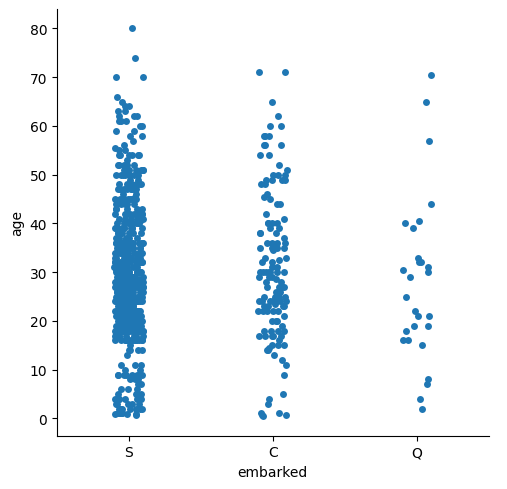

In [107]:
sns.catplot(data=df, x='embarked', y='age') # kind='box'
plt.show()

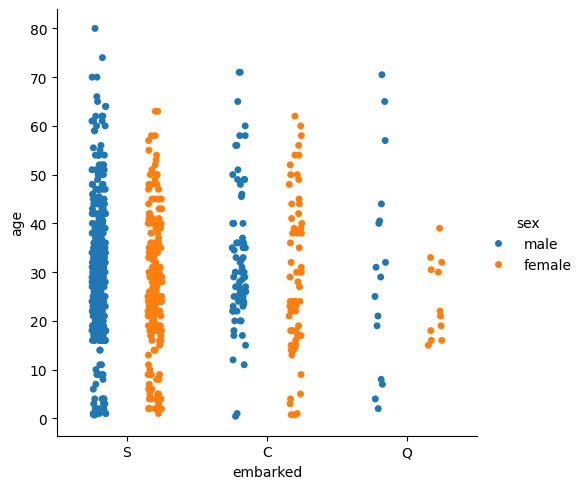

In [109]:
sns.catplot(data=df, x='embarked', y='age', hue='sex', dodge=True)
plt.show()

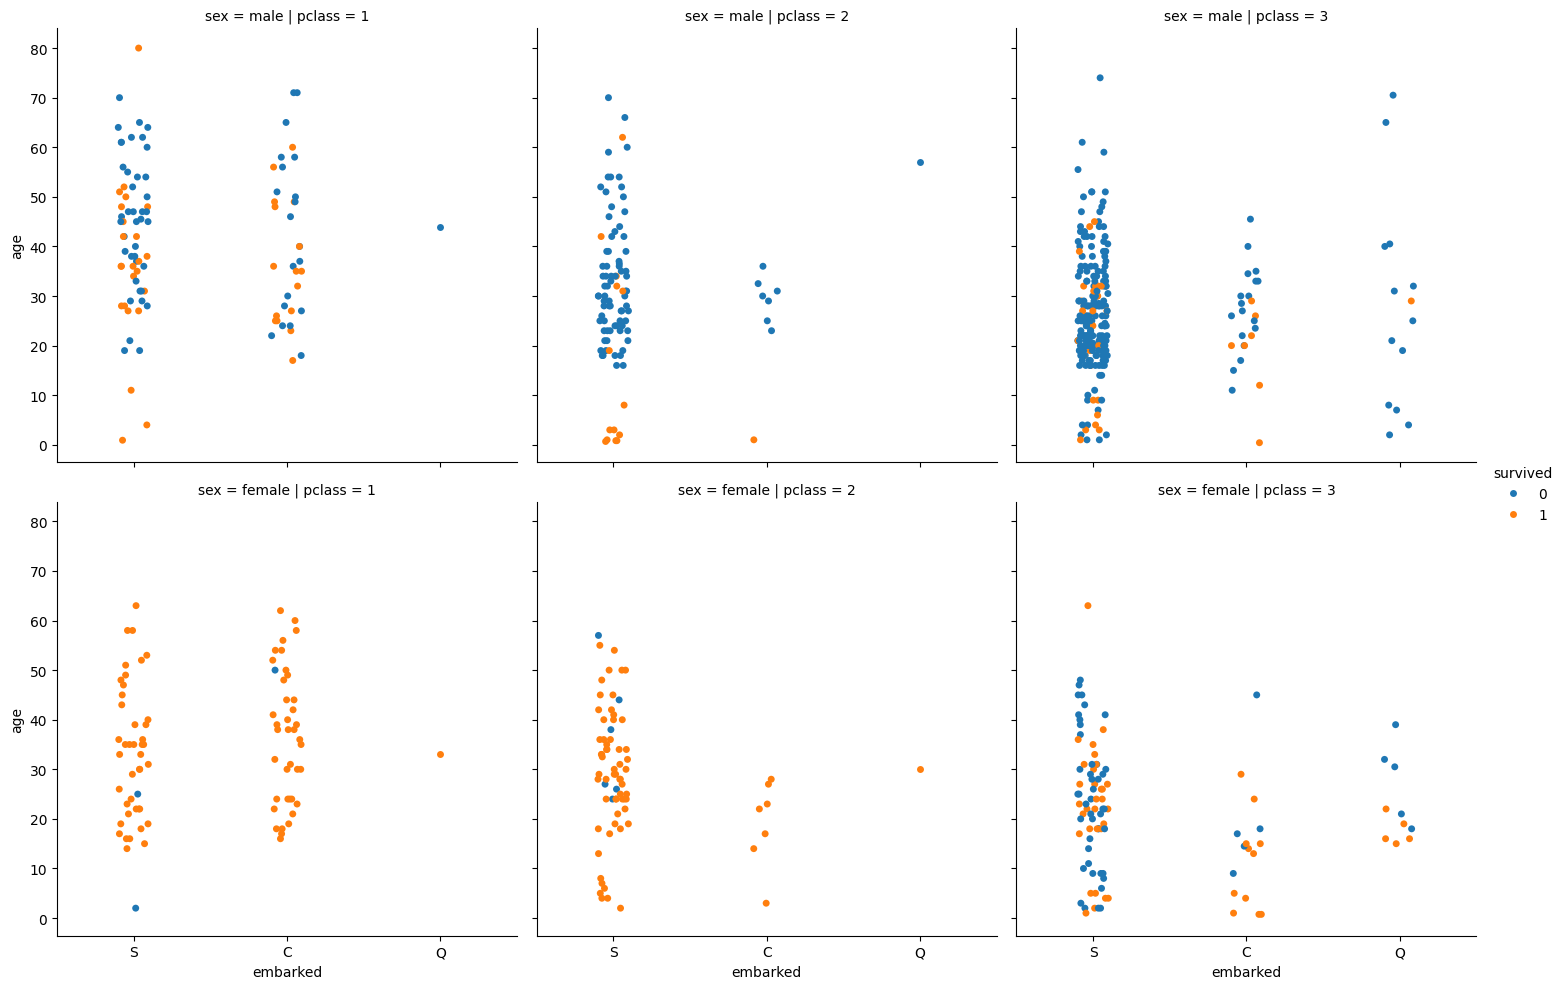

In [115]:
sns.catplot(data=df, x='embarked', y='age', col='pclass', row='sex', hue='survived')
plt.show()
# 明らかClass1の女性客の生き残りが目立つ

カウントプロット

バープロット

ボックスプロット

バイオリンプロット

スウォームプロット

---
 <a id=4></a>
[Topへ](#0)

---
## 以上
    
---